Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Imports

In [34]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Imports

In [50]:
import os
import cv2
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

import joblib

Dataset Path

In [49]:
import os

dataset_path = "/content/drive/MyDrive/archive/content/unified_dataset"

print(os.listdir(dataset_path))

['plastic', 'paper_cardboard', 'glass', 'textiles', 'metal', 'battery', 'trash', 'organic_waste']


In [38]:
categories = [
    "Plastic",
    "Paper_cardboard",
    "Glass",
    "Metal",
    "Organic_waste",
    "Textiles",
    "Battery",
    "Trash"
]

Check Image Counts

In [51]:
for category in os.listdir(dataset_path):
    folder = os.path.join(dataset_path, category)
    print(category, len(os.listdir(folder)))

plastic 0
paper_cardboard 0
glass 8016
textiles 0
metal 992
battery 8000
trash 0
organic_waste 0


Load Images

In [52]:
IMG_SIZE = 32

X = []
y = []

categories = [
    'plastic',
    'paper_cardboard',
    'glass',
    'metal',
    'organic_waste',
    'textiles',
    'battery',
    'trash'
]

for idx, category in enumerate(categories):

    folder = os.path.join(dataset_path, category)

    print("Loading:", category)

    for file in os.listdir(folder):

        if file.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):

            path = os.path.join(folder, file)

            try:
                img = cv2.imread(path)

                if img is None:
                    continue

                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                X.append(img.flatten())

                y.append(idx)

            except:
                pass

print("Total Images Loaded:", len(X))

Loading: plastic
Loading: paper_cardboard
Loading: glass
Loading: metal
Loading: organic_waste
Loading: textiles
Loading: battery
Loading: trash
Total Images Loaded: 17008


Convert to Arrays

In [53]:
X = np.array(X, dtype=np.float32)
y = np.array(y)

print(X.shape)
print(y.shape)

(17008, 3072)
(17008,)


Normalize

In [54]:
X = X / 255.0

Split Data

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (13606, 3072)
Test: (3402, 3072)


Train Logistic Regression

In [56]:
model = LogisticRegression(
    max_iter=1000,
    solver='saga',
    n_jobs=-1
)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(max_iter=1000, n_jobs=-1, solver='saga')

Evaluate

In [58]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7125220458553791


confusion matrix

In [64]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1240   30  333]
 [ 112   30   57]
 [ 400   46 1154]]


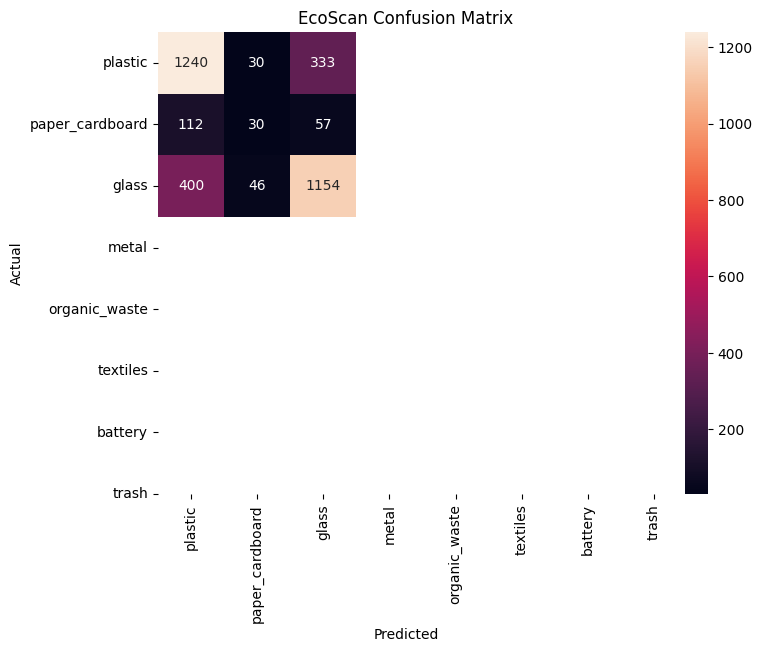

In [66]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=categories,
    yticklabels=categories
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("EcoScan Confusion Matrix")

plt.show()

Detailed Report

In [70]:
import numpy as np

# Get the unique labels present in y_test
unique_labels = np.unique(y_test)

# Filter the original categories list to match the unique labels
filtered_target_names = [categories[i] for i in unique_labels]

print(
    classification_report(
        y_test,
        y_pred,
        labels=unique_labels,
        target_names=filtered_target_names
    )
)

              precision    recall  f1-score   support

       glass       0.71      0.77      0.74      1603
       metal       0.28      0.15      0.20       199
     battery       0.75      0.72      0.73      1600

    accuracy                           0.71      3402
   macro avg       0.58      0.55      0.56      3402
weighted avg       0.70      0.71      0.71      3402



Model Weight

In [61]:
joblib.dump(model, "ecoscan_logistic_model.pkl")

print("Model Saved")

Model Saved
